In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
# Load the full dataset
df = pd.read_csv('final_dataset_with_all_features_v3.1.csv')
print(f'Dataset shape: {df.shape}')
print(f'Columns ({len(df.columns)}):\n{df.columns.tolist()}')

Dataset shape: (651191, 64)
Columns (64):
['url', 'type', 'label', 'url_len', '@', '?', '-', '=', '.', '#', '%', '+', '$', '!', '*', ',', '//', 'digits', 'letters', 'domain', 'abnormal_url', 'https', 'Shortining_Service', 'having_ip_address', 'scan_date', 'web_http_status', 'web_is_live', 'web_ext_ratio', 'web_unique_domains', 'web_favicon', 'web_csp', 'web_xframe', 'web_hsts', 'web_xcontent', 'web_security_score', 'web_forms_count', 'web_password_fields', 'web_hidden_inputs', 'web_has_login', 'web_ssl_valid', 'phish_urgency_words', 'phish_security_words', 'phish_brand_mentions', 'phish_brand_hijack', 'phish_multiple_subdomains', 'phish_long_path', 'phish_many_params', 'phish_suspicious_tld', 'phish_adv_exact_brand_match', 'phish_adv_brand_in_subdomain', 'phish_adv_brand_in_path', 'phish_adv_hyphen_count', 'phish_adv_number_count', 'phish_adv_suspicious_tld', 'phish_adv_long_domain', 'phish_adv_many_subdomains', 'phish_adv_encoded_chars', 'phish_adv_path_keywords', 'phish_adv_has_redir

In [3]:
df.head()

,url,type,label,url_len,@,?,-,=,.,#,...,phish_adv_long_domain,phish_adv_many_subdomains,phish_adv_encoded_chars,phish_adv_path_keywords,phish_adv_has_redirect,phish_adv_many_params,path_has_hacked_terms,suspicious_extension,path_underscore_count,is_gov_edu
0,br-icloud.com.br,phishing,2,16,0,0,1,0,2,0,...,0,0,0,0,0,0,0,0,0,0
1,mp3raid.com/music/krizz_kaliko.html,benign,0,35,0,0,0,0,2,0,...,0,0,0,0,0,0,0,1,1,0
2,bopsecrets.org/rexroth/cr/1.htm,benign,0,31,0,0,0,0,2,0,...,0,0,0,0,0,0,0,1,0,0
3,http://garage-pirenne.be/index.php?option=com_...,defacement,1,84,0,1,1,4,2,0,...,0,0,0,0,0,3,0,1,0,0
4,http://adventure-nicaragua.net/index.php?optio...,defacement,1,235,0,1,1,3,2,0,...,0,0,0,0,0,2,0,1,0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 651191 entries, 0 to 651190
Data columns (total 64 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   url                           651191 non-null  object 
 1   type                          651191 non-null  object 
 2   label                         651191 non-null  int64  
 3   url_len                       651191 non-null  int64  
 4   @                             651191 non-null  int64  
 5   ?                             651191 non-null  int64  
 6   -                             651191 non-null  int64  
 7   =                             651191 non-null  int64  
 8   .                             651191 non-null  int64  
 9   #                             651191 non-null  int64  
 10  %                             651191 non-null  int64  
 11  +                             651191 non-null  int64  
 12  $                             651191 non-nul

In [5]:
mkdir plots

URL Type Distribution (Full Dataset):
type
benign        428103
defacement     96457
phishing       94111
malware        32520
Name: count, dtype: int64

Total URLs: 651,191


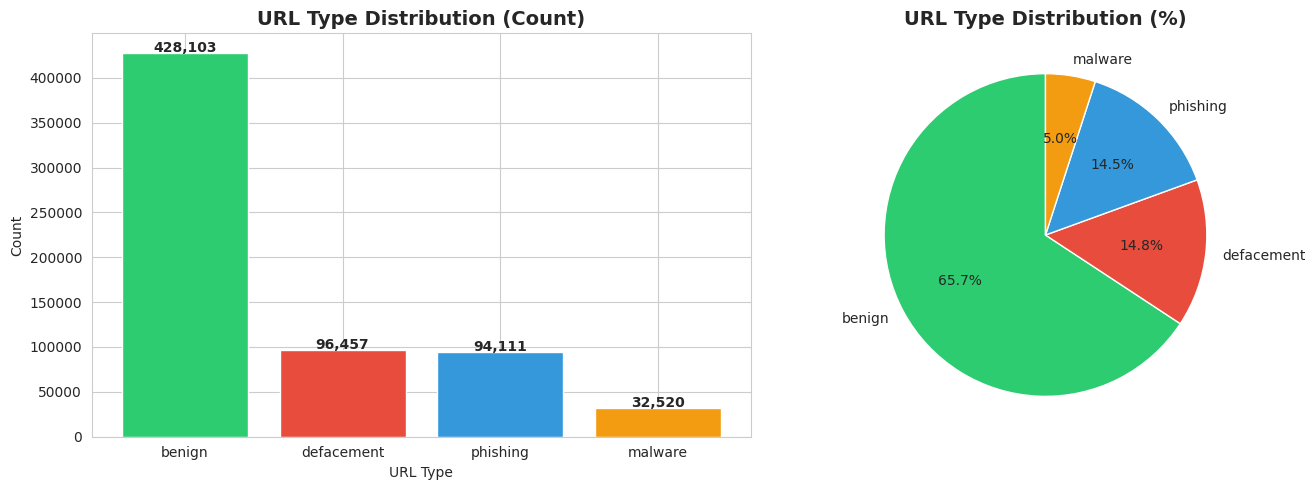

Plot saved.


In [6]:
type_counts = df['type'].value_counts()
print('URL Type Distribution (Full Dataset):')
print(type_counts)
print(f'\nTotal URLs: {len(df):,}')

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['#2ecc71', '#e74c3c', '#3498db', '#f39c12']
axes[0].bar(type_counts.index, type_counts.values, color=colors)
axes[0].set_title('URL Type Distribution (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('URL Type')
axes[0].set_ylabel('Count')
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90)
axes[1].set_title('URL Type Distribution (%)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/01_class_distribution_full.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

In [7]:
import os
os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)
os.makedirs('results', exist_ok=True)

# Filter to benign and phishing only
df_binary = df[df['type'].isin(['benign', 'phishing'])].copy()
df_binary['binary_label'] = (df_binary['type'] == 'phishing').astype(int)

print(f'Filtered dataset shape: {df_binary.shape}')
print(f'\nClass distribution:')
print(df_binary['type'].value_counts())
print(f"\nBinary labels: 0=Benign, 1=Phishing")
print(df_binary['binary_label'].value_counts())

Filtered dataset shape: (522214, 65)

Class distribution:
type
benign      428103
phishing     94111
Name: count, dtype: int64

Binary labels: 0=Benign, 1=Phishing
binary_label
0    428103
1     94111
Name: count, dtype: int64


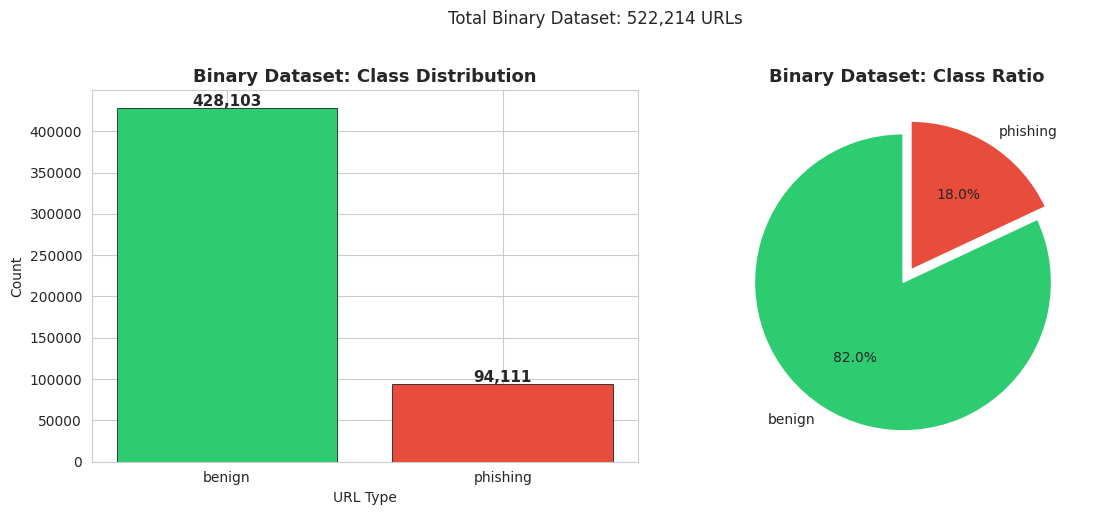

In [8]:
# Plot binary class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df_binary['type'].value_counts()
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_title('Binary Dataset: Class Distribution', fontsize=13, fontweight='bold')
axes[0].set_xlabel('URL Type')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 2000, f'{v:,}', ha='center', fontweight='bold', fontsize=11)

axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Binary Dataset: Class Ratio', fontsize=13, fontweight='bold')

plt.suptitle(f'Total Binary Dataset: {len(df_binary):,} URLs', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('plots/02_binary_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# Define feature columns (exclude metadata columns)
EXCLUDE_COLS = ['url', 'type', 'label', 'domain', 'scan_date', 'binary_label']
FEATURE_COLS = [c for c in df_binary.columns if c not in EXCLUDE_COLS]

print(f'Total feature columns: {len(FEATURE_COLS)}')
print('\nFeature groups:')
url_features = [c for c in FEATURE_COLS if c in ['url_len','@','?','-','=','.','#','%','+','$','!','*',',','//','digits','letters','abnormal_url','https','Shortining_Service','having_ip_address']]
web_features = [c for c in FEATURE_COLS if c.startswith('web_')]
phish_features = [c for c in FEATURE_COLS if c.startswith('phish_')]
other_features = [c for c in FEATURE_COLS if c not in url_features + web_features + phish_features]

print(f'  URL structural features ({len(url_features)}): {url_features}')
print(f'  Web/HTTP features ({len(web_features)}): {web_features}')
print(f'  Phishing-specific features ({len(phish_features)}): {phish_features}')
print(f'  Other features ({len(other_features)}): {other_features}')

Total feature columns: 59

Feature groups:
  URL structural features (20): ['url_len', '@', '?', '-', '=', '.', '#', '%', '+', '$', '!', '*', ',', '//', 'digits', 'letters', 'abnormal_url', 'https', 'Shortining_Service', 'having_ip_address']
  Web/HTTP features (15): ['web_http_status', 'web_is_live', 'web_ext_ratio', 'web_unique_domains', 'web_favicon', 'web_csp', 'web_xframe', 'web_hsts', 'web_xcontent', 'web_security_score', 'web_forms_count', 'web_password_fields', 'web_hidden_inputs', 'web_has_login', 'web_ssl_valid']
  Phishing-specific features (20): ['phish_urgency_words', 'phish_security_words', 'phish_brand_mentions', 'phish_brand_hijack', 'phish_multiple_subdomains', 'phish_long_path', 'phish_many_params', 'phish_suspicious_tld', 'phish_adv_exact_brand_match', 'phish_adv_brand_in_subdomain', 'phish_adv_brand_in_path', 'phish_adv_hyphen_count', 'phish_adv_number_count', 'phish_adv_suspicious_tld', 'phish_adv_long_domain', 'phish_adv_many_subdomains', 'phish_adv_encoded_chars'

In [10]:
null_counts = df_binary[FEATURE_COLS].isnull().sum()
null_cols = null_counts[null_counts > 0]

if len(null_cols) == 0:
    print('No missing values in feature columns.')
else:
    print(f'Columns with missing values:\n{null_cols}')
    df_binary[FEATURE_COLS] = df_binary[FEATURE_COLS].fillna(df_binary[FEATURE_COLS].median())
    print('Missing values filled with column median.')

print(f'\nFinal null count: {df_binary[FEATURE_COLS].isnull().sum().sum()}')

No missing values in feature columns.

Final null count: 0


In [11]:
desc = df_binary[FEATURE_COLS].describe().T
desc

,count,mean,std,min,25%,50%,75%,max
url_len,522214.0,55.111933,44.412233,1.0,30.0,43.0,67.0,2175.0
@,522214.0,0.002683,0.059797,0.0,0.0,0.0,0.0,10.0
?,522214.0,0.165796,0.405223,0.0,0.0,0.0,0.0,20.0
-,522214.0,1.591474,3.091303,0.0,0.0,0.0,2.0,87.0
=,522214.0,0.297935,0.972651,0.0,0.0,0.0,0.0,51.0
.,522214.0,1.933763,1.485509,0.0,1.0,2.0,2.0,42.0
#,522214.0,0.001082,0.036043,0.0,0.0,0.0,0.0,6.0
%,522214.0,0.451596,4.506584,0.0,0.0,0.0,0.0,231.0
+,522214.0,0.082568,0.683282,0.0,0.0,0.0,0.0,37.0
$,522214.0,0.000285,0.025998,0.0,0.0,0.0,0.0,6.0


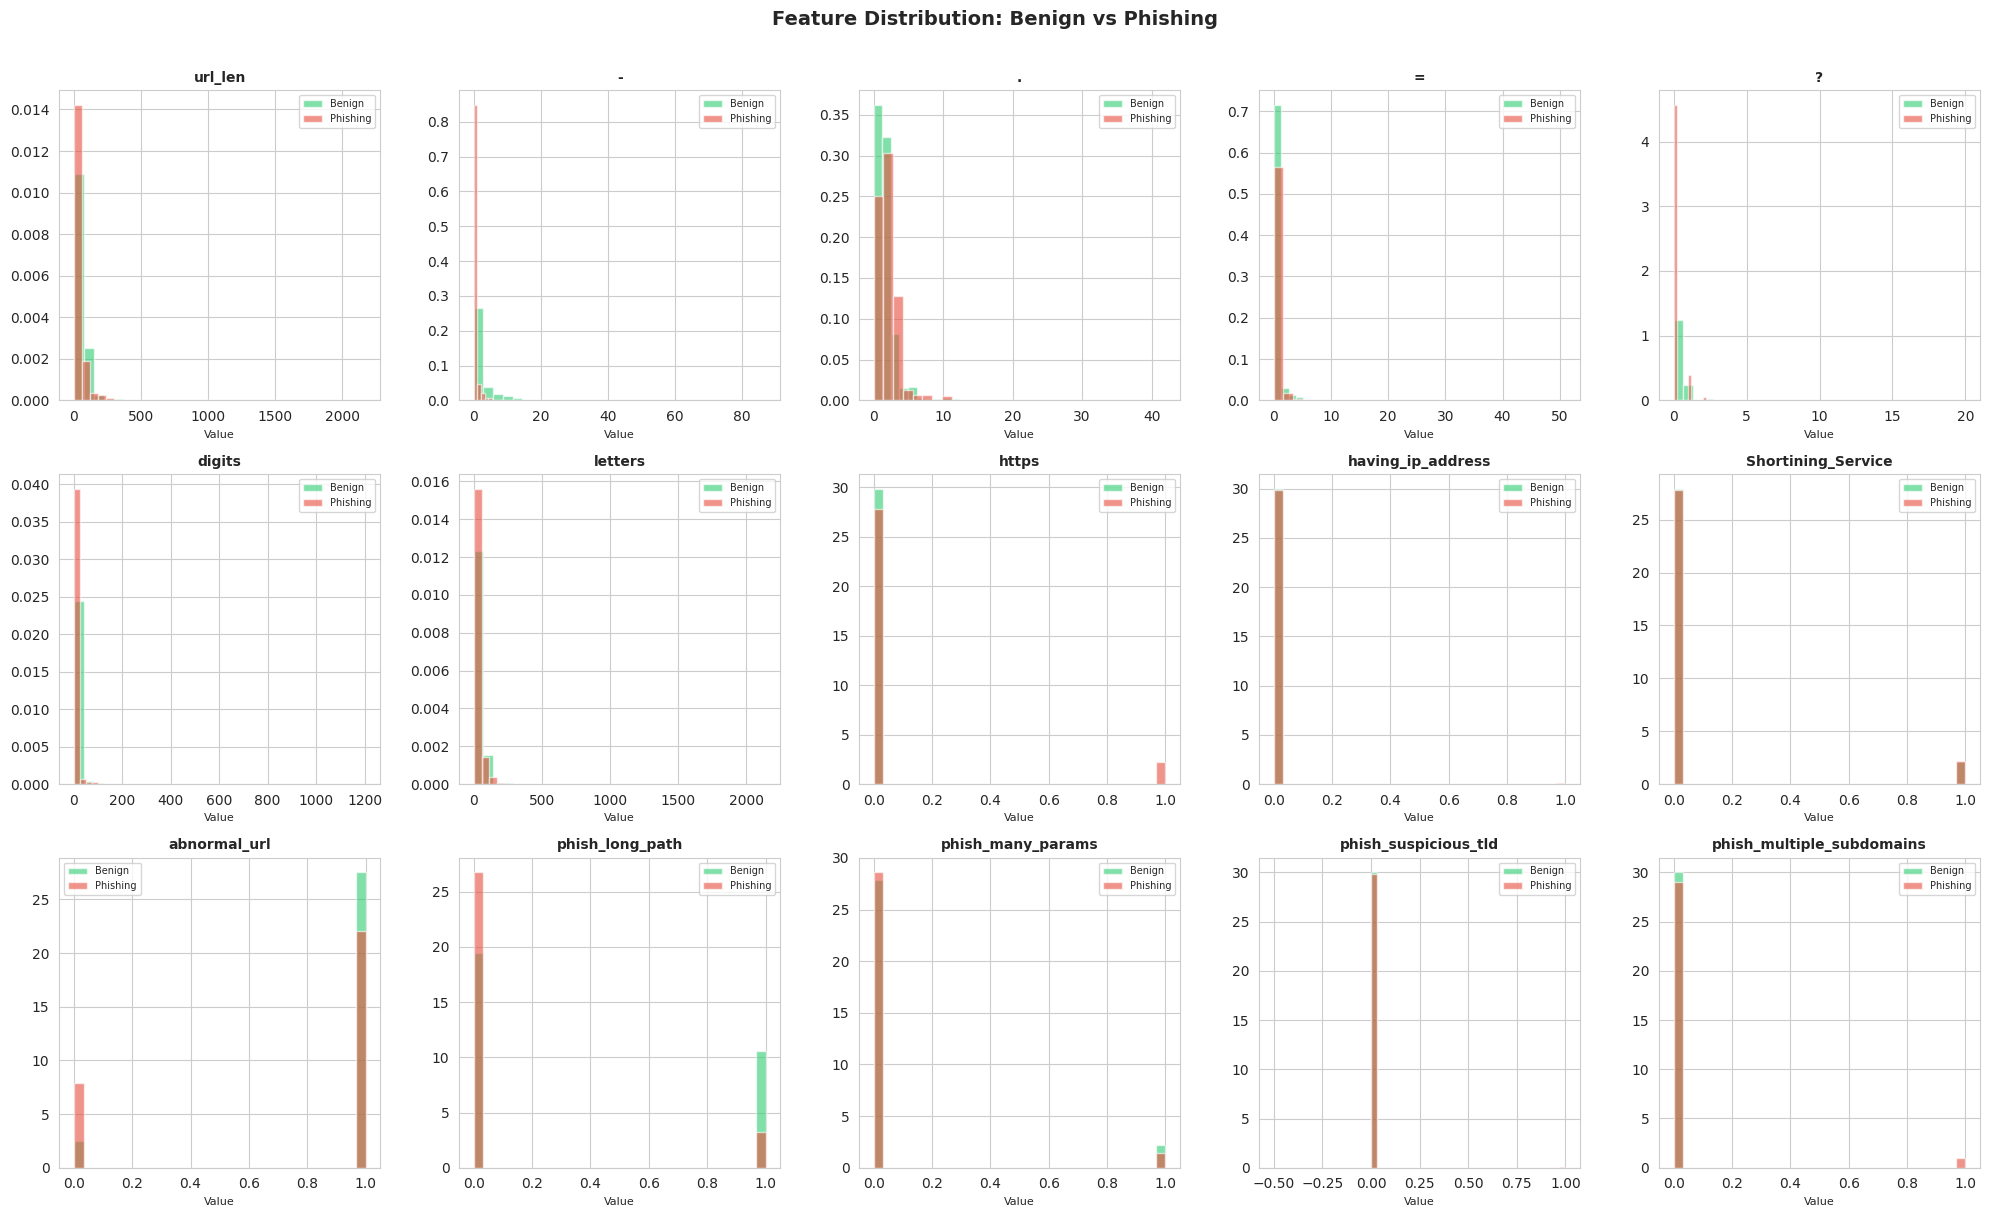

In [12]:
# Compare key URL features between phishing and benign
key_features = ['url_len', '-', '.', '=', '?', 'digits', 'letters',
                'https', 'having_ip_address', 'Shortining_Service',
                'abnormal_url', 'phish_long_path', 'phish_many_params',
                'phish_suspicious_tld', 'phish_multiple_subdomains']

benign_df = df_binary[df_binary['binary_label'] == 0]
phishing_df = df_binary[df_binary['binary_label'] == 1]

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, feat in enumerate(key_features):
    ax = axes[i]
    ax.hist(benign_df[feat], bins=30, alpha=0.6, color='#2ecc71', label='Benign', density=True)
    ax.hist(phishing_df[feat], bins=30, alpha=0.6, color='#e74c3c', label='Phishing', density=True)
    ax.set_title(feat, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.set_xlabel('Value', fontsize=8)

plt.suptitle('Feature Distribution: Benign vs Phishing', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plots/03_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

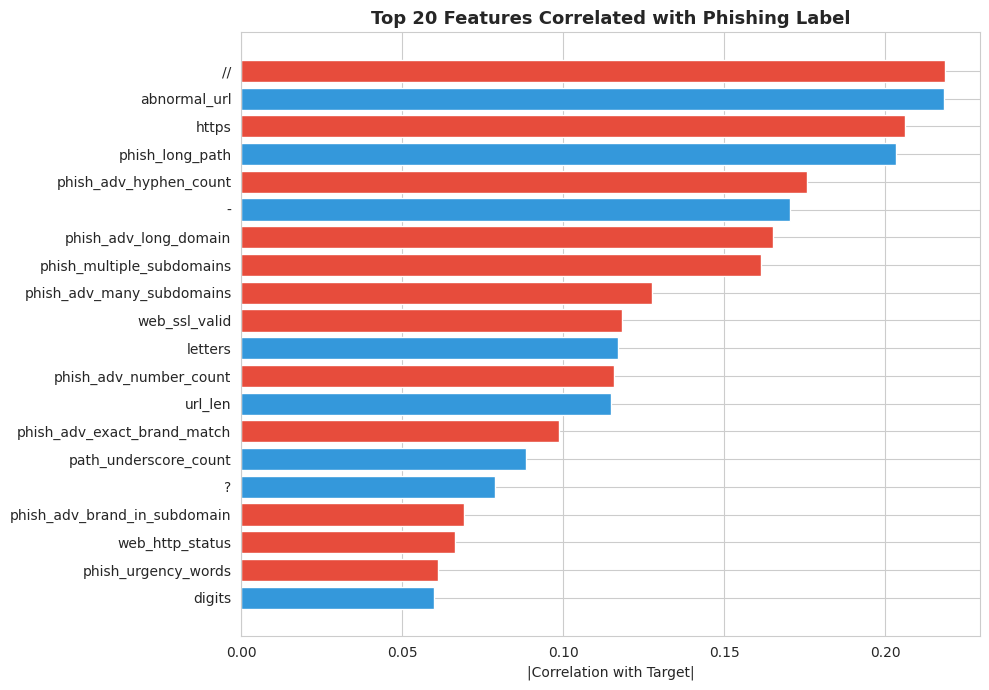


Top 20 features by correlation magnitude:
  //                                      : 0.2186 -> leans phishing
  abnormal_url                            : 0.2182 -> leans benign
  https                                   : 0.2061 -> leans phishing
  phish_long_path                         : 0.2034 -> leans benign
  phish_adv_hyphen_count                  : 0.1756 -> leans phishing
  -                                       : 0.1704 -> leans benign
  phish_adv_long_domain                   : 0.1651 -> leans phishing
  phish_multiple_subdomains               : 0.1613 -> leans phishing
  phish_adv_many_subdomains               : 0.1275 -> leans phishing
  web_ssl_valid                           : 0.1184 -> leans phishing
  letters                                 : 0.1169 -> leans benign
  phish_adv_number_count                  : 0.1156 -> leans phishing
  url_len                                 : 0.1149 -> leans benign
  phish_adv_exact_brand_match             : 0.0987 -> leans phishing
 

In [13]:
# Top 20 features correlated with target
corr_with_label = df_binary[FEATURE_COLS + ['binary_label']].corr()['binary_label'].drop('binary_label')
top_corr = corr_with_label.abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 7))
colors_bar = ['#e74c3c' if corr_with_label[f] > 0 else '#3498db' for f in top_corr.index]
plt.barh(range(len(top_corr)), top_corr.values, color=colors_bar)
plt.yticks(range(len(top_corr)), top_corr.index)
plt.xlabel('|Correlation with Target|')
plt.title('Top 20 Features Correlated with Phishing Label', fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('plots/04_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop 20 features by correlation magnitude:')
for feat, val in top_corr.items():
    direction = 'phishing' if corr_with_label[feat] > 0 else 'benign'
    print(f'  {feat:40s}: {val:.4f} -> leans {direction}')

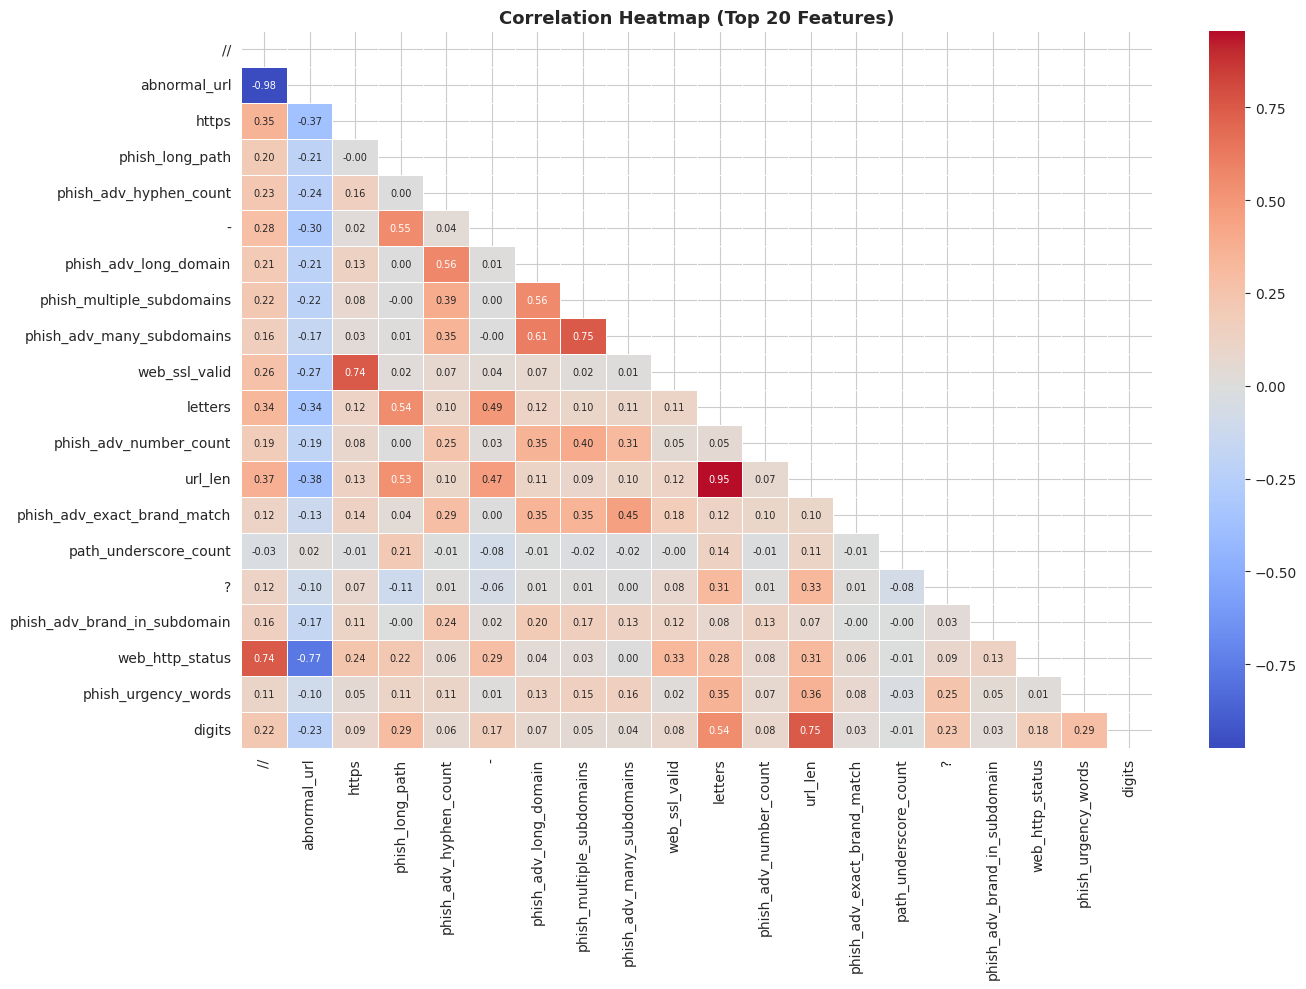

In [14]:
# Full correlation heatmap of top 20 features
top20_cols = top_corr.index.tolist()
plt.figure(figsize=(14, 10))
corr_matrix = df_binary[top20_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Heatmap (Top 20 Features)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/05_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

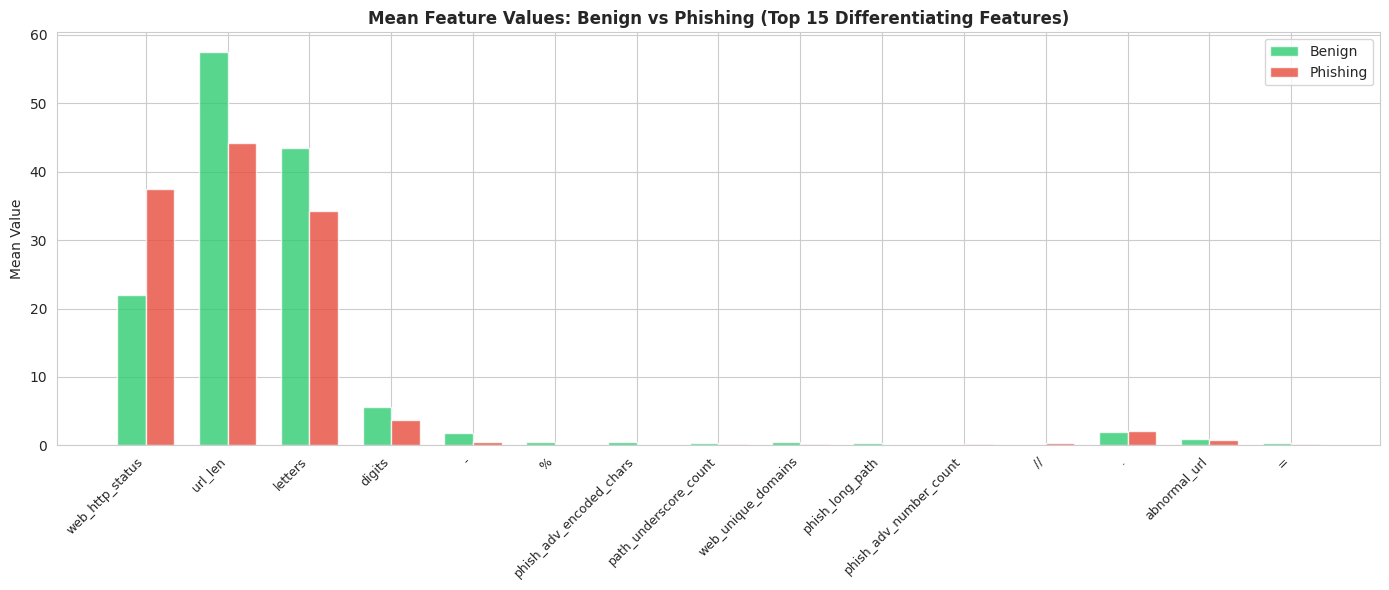

In [15]:
mean_comparison = df_binary.groupby('type')[FEATURE_COLS].mean().T
mean_comparison['diff'] = abs(mean_comparison['phishing'] - mean_comparison['benign'])
top_diff = mean_comparison.sort_values('diff', ascending=False).head(15)

x = np.arange(len(top_diff))
width = 0.35
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - width/2, top_diff['benign'], width, label='Benign', color='#2ecc71', alpha=0.8)
ax.bar(x + width/2, top_diff['phishing'], width, label='Phishing', color='#e74c3c', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(top_diff.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Mean Feature Values: Benign vs Phishing (Top 15 Differentiating Features)',
             fontsize=12, fontweight='bold')
ax.set_ylabel('Mean Value')
ax.legend()
plt.tight_layout()
plt.savefig('plots/06_mean_feature_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

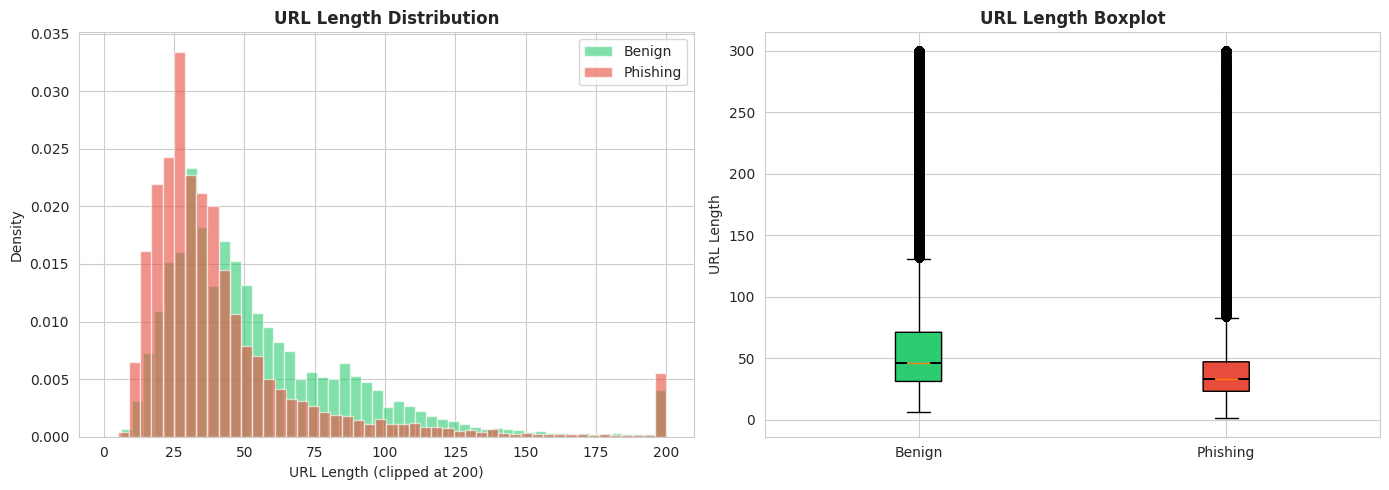

Mean URL length - Benign: 57.5, Phishing: 44.2


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution
axes[0].hist(benign_df['url_len'].clip(upper=200), bins=50, alpha=0.6, color='#2ecc71', label='Benign', density=True)
axes[0].hist(phishing_df['url_len'].clip(upper=200), bins=50, alpha=0.6, color='#e74c3c', label='Phishing', density=True)
axes[0].set_xlabel('URL Length (clipped at 200)')
axes[0].set_ylabel('Density')
axes[0].set_title('URL Length Distribution', fontsize=12, fontweight='bold')
axes[0].legend()

# Boxplot
data_to_plot = [benign_df['url_len'].clip(upper=300).values,
                phishing_df['url_len'].clip(upper=300).values]
bp = axes[1].boxplot(data_to_plot, labels=['Benign', 'Phishing'],
                     patch_artist=True, notch=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#e74c3c')
axes[1].set_ylabel('URL Length')
axes[1].set_title('URL Length Boxplot', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('plots/07_url_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean URL length - Benign: {benign_df['url_len'].mean():.1f}, Phishing: {phishing_df['url_len'].mean():.1f}")

In [17]:
X = df_binary[FEATURE_COLS].values
y = df_binary['binary_label'].values

print(f'Feature matrix shape: {X.shape}')
print(f'Target vector shape: {y.shape}')
print(f'Class balance: {np.bincount(y)}')

# Min-Max Normalization (as described in paper Eq.4)
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

print(f'\nAfter normalization:')
print(f'  Min: {X_scaled.min():.4f}')
print(f'  Max: {X_scaled.max():.4f}')
print(f'  Mean: {X_scaled.mean():.4f}')

Feature matrix shape: (522214, 59)
Target vector shape: (522214,)
Class balance: [428103  94111]

After normalization:
  Min: 0.0000
  Max: 1.0000
  Mean: 0.0391


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.20, random_state=42, stratify=y
)

print('Dataset Split (80:20):')
print(f'  Training set  : {X_train.shape[0]:,} samples')
print(f'  Test set      : {X_test.shape[0]:,} samples')
print(f'  Features      : {X_train.shape[1]}')
print(f'\nTraining class balance: {np.bincount(y_train)}')
print(f'Test class balance    : {np.bincount(y_test)}')

Dataset Split (80:20):
  Training set  : 417,771 samples
  Test set      : 104,443 samples
  Features      : 59

Training class balance: [342482  75289]
Test class balance    : [85621 18822]


In [19]:
import pickle

# Save preprocessed splits
np.save('results/X_train.npy', X_train)
np.save('results/X_test.npy', X_test)
np.save('results/y_train.npy', y_train)
np.save('results/y_test.npy', y_test)

# Save scaler
with open('models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Save feature column names
with open('models/feature_cols.pkl', 'wb') as f:
    pickle.dump(FEATURE_COLS, f)

print('Saved:')
print('  results/X_train.npy, X_test.npy, y_train.npy, y_test.npy')
print('  models/scaler.pkl')
print('  models/feature_cols.pkl')

Saved:
  results/X_train.npy, X_test.npy, y_train.npy, y_test.npy
  models/scaler.pkl
  models/feature_cols.pkl


In [20]:
print('=' * 55)
print('       EDA & PREPROCESSING SUMMARY')
print('=' * 55)
print(f'Full dataset size        : {len(df):,} URLs')
print(f'After filtering (binary) : {len(df_binary):,} URLs')
print(f'  - Benign               : {(y==0).sum():,} ({(y==0).mean()*100:.1f}%)')
print(f'  - Phishing             : {(y==1).sum():,} ({(y==1).mean()*100:.1f}%)')
print(f'Feature columns used     : {len(FEATURE_COLS)}')
print(f'Missing values           : 0 (none in features)')
print(f'Normalization            : Min-Max [0, 1]')
print(f'Train / Test split       : 80% / 20%')
print(f'  - Train samples        : {X_train.shape[0]:,}')
print(f'  - Test samples         : {X_test.shape[0]:,}')
print('=' * 55)

       EDA & PREPROCESSING SUMMARY
Full dataset size        : 651,191 URLs
After filtering (binary) : 522,214 URLs
  - Benign               : 428,103 (82.0%)
  - Phishing             : 94,111 (18.0%)
Feature columns used     : 59
Missing values           : 0 (none in features)
Normalization            : Min-Max [0, 1]
Train / Test split       : 80% / 20%
  - Train samples        : 417,771
  - Test samples         : 104,443


In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

plt.rcParams['figure.figsize'] = (10, 6)
sns.set_style('whitegrid')
tf.random.set_seed(42)
np.random.seed(42)

print(f'TensorFlow version: {tf.__version__}')
print('GPU available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [22]:
X_train = np.load('results/X_train.npy')
X_test  = np.load('results/X_test.npy')
y_train = np.load('results/y_train.npy')
y_test  = np.load('results/y_test.npy')

with open('models/feature_cols.pkl', 'rb') as f:
    FEATURE_COLS = pickle.load(f)

NUM_FEATURES = X_train.shape[1]
print(f'X_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')
print(f'y_train shape : {y_train.shape}')
print(f'y_test shape  : {y_test.shape}')
print(f'Num features  : {NUM_FEATURES}')

X_train shape : (417771, 59)
X_test shape  : (104443, 59)
y_train shape : (417771,)
y_test shape  : (104443,)
Num features  : 59


In [23]:
# Reshape: (samples, features) -> (samples, features, 1) for Conv1D
X_train_3d = X_train.reshape(X_train.shape[0], NUM_FEATURES, 1)
X_test_3d  = X_test.reshape(X_test.shape[0], NUM_FEATURES, 1)

print(f'Reshaped X_train: {X_train_3d.shape}')
print(f'Reshaped X_test : {X_test_3d.shape}')

Reshaped X_train: (417771, 59, 1)
Reshaped X_test : (104443, 59, 1)


In [24]:
def conv_block(x, filters=64, kernel_size=3):
    """Convolutional Block: Conv1D + BatchNorm + ReLU (as in paper)"""
    x = layers.Conv1D(filters, kernel_size, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    return x


def inverted_residual_block(x, filters=64, kernel_size=3):
    """
    Inverted Residual Block (as in paper):
    SeparableConv1D + BN + ReLU -> Conv1D + BN + ReLU -> Add (skip connection)
    """
    shortcut = x  # skip connection

    # Separable convolution (depthwise + pointwise)
    x = layers.SeparableConv1D(filters, kernel_size, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Pointwise convolution
    x = layers.Conv1D(filters, 1, padding='same', use_bias=False)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    # Skip connection (add shortcut)
    # Adjust shortcut channels if needed
    if shortcut.shape[-1] != filters:
        shortcut = layers.Conv1D(filters, 1, padding='same', use_bias=False)(shortcut)
        shortcut = layers.BatchNormalization()(shortcut)

    x = layers.Add()([x, shortcut])
    return x


def build_resmlp(input_shape, num_filters=64, num_inv_res_blocks=7, num_classes=2, dropout_rate=0.3):
    """
    ResMLP: Residual Pipeline + MLP Output Block
    Exactly as described in the paper:
    - 1 Conv Block
    - 7 Inverted Residual Blocks
    - 1 Conv Block
    - Output Block (MaxPool + Flatten + Dense + Dropout + Softmax)
    """
    inputs = keras.Input(shape=input_shape, name='feature_input')

    # --- Residual Pipeline ---
    # Entry Conv Block
    x = conv_block(inputs, filters=num_filters, kernel_size=3)

    # 7 Inverted Residual Blocks (asynchronous as per paper)
    for i in range(num_inv_res_blocks):
        x = inverted_residual_block(x, filters=num_filters, kernel_size=3)

    # Exit Conv Block
    x = conv_block(x, filters=num_filters, kernel_size=3)

    # --- Output Block ---
    # Max Pooling (shrink spatial size)
    x = layers.GlobalMaxPooling1D()(x)

    # Dense layers (MLP)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)

    # Output: Softmax (binary classification)
    if num_classes == 2:
        outputs = layers.Dense(1, activation='sigmoid', name='output')(x)
    else:
        outputs = layers.Dense(num_classes, activation='softmax', name='output')(x)

    model = Model(inputs=inputs, outputs=outputs, name='ResMLP')
    return model


# Build model
INPUT_SHAPE = (NUM_FEATURES, 1)
model = build_resmlp(INPUT_SHAPE, num_filters=32, num_inv_res_blocks=3, num_classes=2)
model.summary()

Model: "ResMLP"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ feature_input       │ (None, 59, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 59, 32)    │         96 │ feature_input[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 59, 32)    │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 59, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d    │ (None, 59, 32)    │      1,120 │ activation[0][0]  │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 59, 32)    │        128 │ separable_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 59, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 59, 32)    │      1,024 │ activation_1[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 59, 32)    │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 59, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 59, 32)    │          0 │ activation_2[0][… │
│                     │                   │            │ activation[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ separable_conv1d_1  │ (None, 59, 32)    │      1,120 │ add[0][0]         │
│ (SeparableConv1D)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 59, 32)    │        128 │ separable_conv1d… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 59, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 59, 32)    │      1,024 │ activation_3[0][… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 59, 32)    │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 59, 32)    │          0 │ batch_normalizat… │
│ (Activation)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 59, 32)    │          0 │ activation_4[0][

 Total params: 23,169 (90.50 KB)

 Trainable params: 22,657 (88.50 KB)

 Non-trainable params: 512 (2.00 KB)

In [25]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy',
             keras.metrics.Precision(name='precision'),
             keras.metrics.Recall(name='recall'),
             keras.metrics.AUC(name='auc')]
)

print('Model compiled successfully.')
print(f'Total parameters: {model.count_params():,}')

Model compiled successfully.
Total parameters: 23,169


In [26]:
try:
    keras.utils.plot_model(model, to_file='plots/resmlp_architecture.png',
                           show_shapes=True, show_layer_names=True, dpi=80)

except Exception as e:
    print(f'Architecture plot skipped: {e}')
    print('Model summary printed above instead.')

In [27]:
os.makedirs('models', exist_ok=True)

callbacks = [
    # Save best model (as per paper: best accuracy is saved)
    ModelCheckpoint(
        'models/resmlp_best.keras',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    # Stop if val_loss doesn't improve (paper uses 50 epochs, stops if same error for all 50)
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    # Reduce LR on plateau
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

print('Callbacks configured:')
print('  - ModelCheckpoint: saves best val_accuracy model')
print('  - EarlyStopping: patience=10 on val_loss')
print('  - ReduceLROnPlateau: factor=0.5, patience=5')

Callbacks configured:
  - ModelCheckpoint: saves best val_accuracy model
  - EarlyStopping: patience=10 on val_loss
  - ReduceLROnPlateau: factor=0.5, patience=5


In [28]:
EPOCHS = 50
BATCH_SIZE = 16  # as specified in paper

print(f'Training ResMLP for {EPOCHS} epochs with batch size {BATCH_SIZE}...')
print(f'Training samples: {X_train_3d.shape[0]:,}')
print(f'Validation samples: {X_test_3d.shape[0]:,}')
print('-' * 50)

history = model.fit(
    X_train_3d, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=(X_test_3d, y_test),
    callbacks=callbacks,
    verbose=1
)

print('\nTraining complete.')

Training ResMLP for 50 epochs with batch size 16...
Training samples: 417,771
Validation samples: 104,443
--------------------------------------------------
Epoch 1/50
26111/26111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8493 - auc: 0.7923 - loss: 0.3686 - precision: 0.8143 - recall: 0.2050
Epoch 1: val_accuracy improved from None to 0.86364, saving model to models/resmlp_best.keras

Epoch 1: finished saving model to models/resmlp_best.keras
26111/26111 ━━━━━━━━━━━━━━━━━━━━ 143s 5ms/step - accuracy: 0.8570 - auc: 0.8348 - loss: 0.3406 - precision: 0.8684 - recall: 0.2436 - val_accuracy: 0.8636 - val_auc: 0.8634 - val_loss: 0.3161 - val_precision: 0.9202 - val_recall: 0.2664 - learning_rate: 0.0010
Epoch 2/50
26108/26111 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8627 - auc: 0.8579 - loss: 0.3181 - precision: 0.8862 - recall: 0.2718
Epoch 2: val_accuracy improved from 0.86364 to 0.86964, saving model to models/resmlp_best.keras

Epoch 2: finished saving model to models/resmlp_

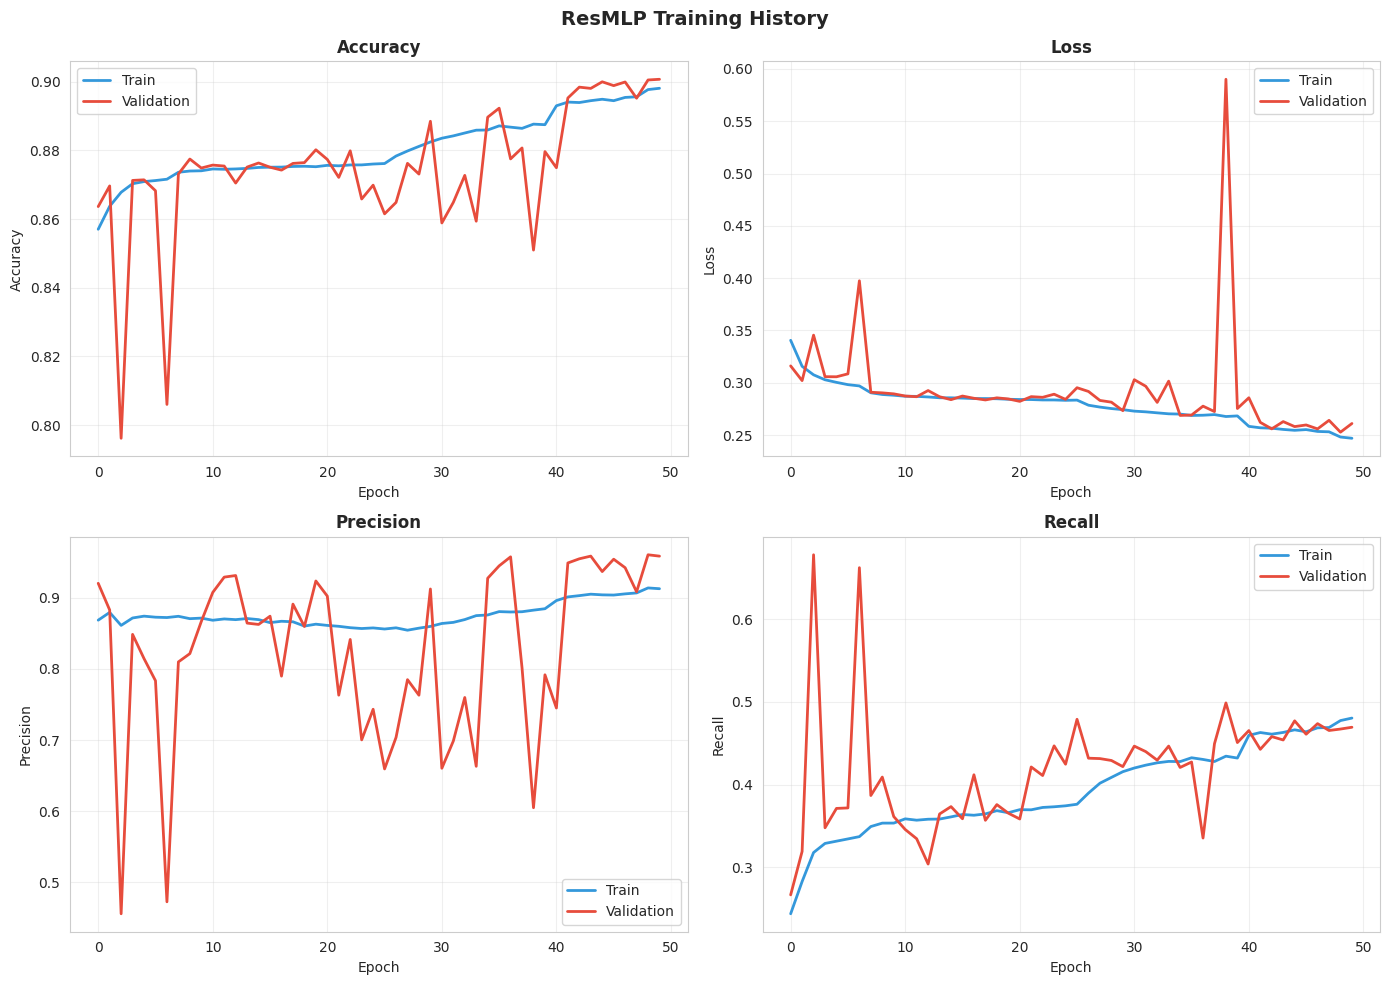

Best epoch: 50
Best val_accuracy: 0.9007


In [29]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = [
    ('accuracy', 'val_accuracy', 'Accuracy'),
    ('loss', 'val_loss', 'Loss'),
    ('precision', 'val_precision', 'Precision'),
    ('recall', 'val_recall', 'Recall')
]

for ax, (train_key, val_key, title) in zip(axes.flatten(), metrics):
    if train_key in history.history:
        ax.plot(history.history[train_key], label='Train', color='#3498db', linewidth=2)
    if val_key in history.history:
        ax.plot(history.history[val_key], label='Validation', color='#e74c3c', linewidth=2)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(title)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('ResMLP Training History', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/08_resmlp_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

# Print best epoch
best_epoch = np.argmax(history.history['val_accuracy'])
print(f"Best epoch: {best_epoch + 1}")
print(f"Best val_accuracy: {history.history['val_accuracy'][best_epoch]:.4f}")

In [30]:
# Load the best saved model
best_model = keras.models.load_model('models/resmlp_best.keras')
print('Best model loaded.')

# Predict
y_pred_prob = best_model.predict(X_test_3d, batch_size=512).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)  # threshold = 0.5 as per paper

print(f'Predictions shape: {y_pred.shape}')
print(f'Unique predictions: {np.unique(y_pred, return_counts=True)}')

Best model loaded.
204/204 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step
Predictions shape: (104443,)
Unique predictions: (array([0, 1]), array([95225,  9218]))


In [31]:
acc       = accuracy_score(y_test, y_pred)
prec      = precision_score(y_test, y_pred)
rec       = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_prob)
avg_prec  = average_precision_score(y_test, y_pred_prob)

print('=' * 50)
print('     ResMLP PERFORMANCE METRICS')
print('=' * 50)
print(f'  Accuracy  : {acc*100:.2f}%')
print(f'  Precision : {prec*100:.2f}%')
print(f'  Recall    : {rec*100:.2f}%')
print(f'  F1 Score  : {f1*100:.2f}%')
print(f'  ROC AUC   : {roc_auc:.4f}')
print(f'  Avg Prec  : {avg_prec:.4f}')
print('=' * 50)
print(f'  Paper target accuracy: 98.29%')

resmlp_results = {
    'Model': 'ResMLP',
    'Accuracy': acc, 'Precision': prec,
    'Recall': rec, 'F1 Score': f1,
    'ROC AUC': roc_auc
}

  Accuracy  : 90.07%


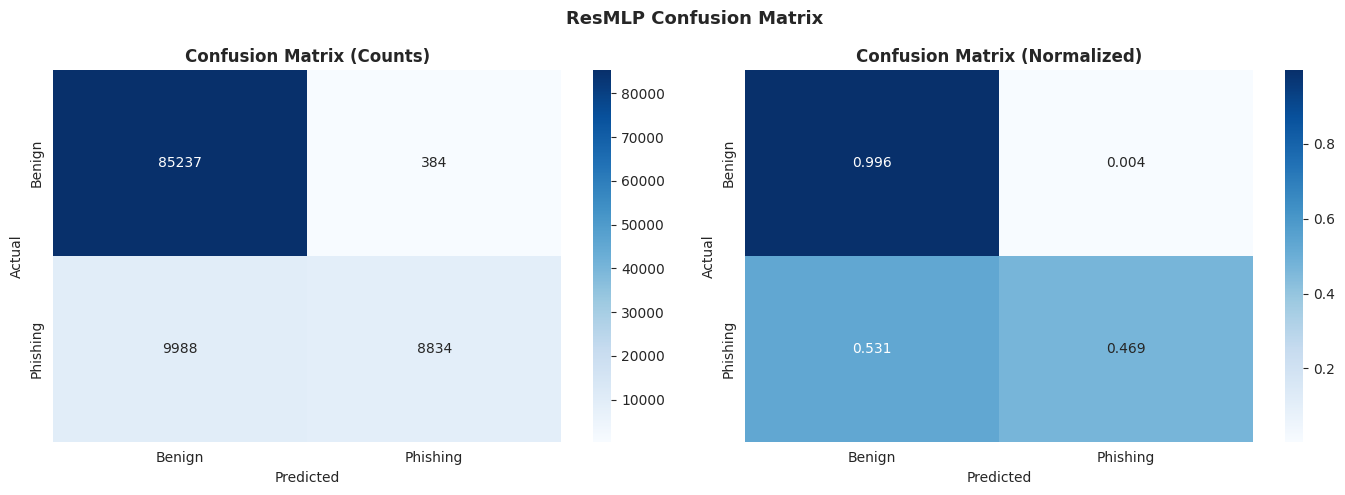

True Negatives (Benign correct)    : 85,237
False Positives (Benign as Phish)  : 384
False Negatives (Phish as Benign)  : 9,988
True Positives (Phish correct)     : 8,834


In [32]:
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Benign', 'Phishing'],
            yticklabels=['Benign', 'Phishing'])
axes[0].set_title('Confusion Matrix (Counts)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.3f', cmap='Blues', ax=axes[1],
            xticklabels=['Benign', 'Phishing'],
            yticklabels=['Benign', 'Phishing'])
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('ResMLP Confusion Matrix', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/09_resmlp_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Negatives (Benign correct)    : {tn:,}')
print(f'False Positives (Benign as Phish)  : {fp:,}')
print(f'False Negatives (Phish as Benign)  : {fn:,}')
print(f'True Positives (Phish correct)     : {tp:,}')

In [ ]:
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y_test, y_pred_prob)

plt.figure(figsize=(8, 7))
plt.plot(recall_vals, precision_vals, color='#3498db', lw=2.5,
         label=f'ResMLP (AP = {avg_prec:.4f})')
plt.fill_between(recall_vals, precision_vals, alpha=0.1, color='#3498db')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve — ResMLP', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/11_resmlp_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()

In [35]:
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Benign', 'Phishing']))

Classification Report:
              precision    recall  f1-score   support

      Benign       0.90      1.00      0.94     85621
    Phishing       0.96      0.47      0.63     18822

    accuracy                           0.90    104443
   macro avg       0.93      0.73      0.79    104443
weighted avg       0.91      0.90      0.89    104443



In [38]:
import json
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, average_precision_score
)

# Recalculate metrics to ensure they are defined, assuming y_test, y_pred, y_pred_prob and history are available.
acc       = accuracy_score(y_test, y_pred)
prec      = precision_score(y_test, y_pred)
rec       = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_prob)
avg_prec  = average_precision_score(y_test, y_pred_prob)
cm        = confusion_matrix(y_test, y_pred)

results = {
    'model': 'ResMLP',
    'accuracy': float(acc),
    'precision': float(prec),
    'recall': float(rec),
    'f1_score': float(f1),
    'roc_auc': float(roc_auc),
    'avg_precision': float(avg_prec),
    'confusion_matrix': cm.tolist(),
    'epochs_trained': len(history.history['loss']),
    'best_epoch': int(np.argmax(history.history['val_accuracy'])) + 1
}

with open('results/resmlp_results.json', 'w') as f:
    json.dump(results, f, indent=4)

# Save history
history_df = pd.DataFrame(history.history)
history_df.to_csv('results/resmlp_training_history.csv', index=False)

print('Results saved to results/resmlp_results.json')
print('History saved to results/resmlp_training_history.csv')

Results saved to results/resmlp_results.json
History saved to results/resmlp_training_history.csv


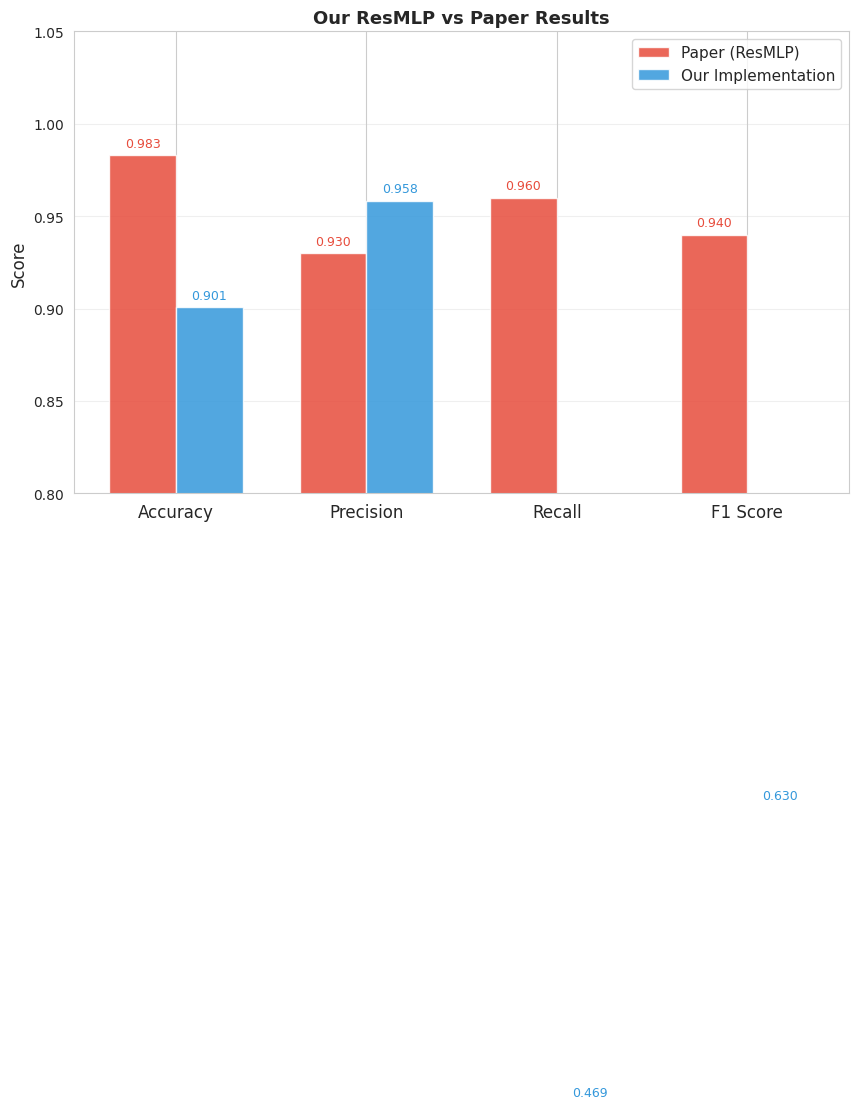


Comparison Table:
            Paper      Ours  Difference
Accuracy   0.9829  0.900692   -0.082208
Precision  0.9300  0.958342    0.028342
Recall     0.9600  0.469344   -0.490656
F1 Score   0.9400  0.630100   -0.309900


In [39]:
paper_results = {
    'Accuracy':  0.9829,
    'Precision': 0.93,
    'Recall':    0.96,
    'F1 Score':  0.94
}

our_results = {
    'Accuracy':  acc,
    'Precision': prec,
    'Recall':    rec,
    'F1 Score':  f1
}

metrics = list(paper_results.keys())
x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, [paper_results[m] for m in metrics],
               width, label='Paper (ResMLP)', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + width/2, [our_results[m] for m in metrics],
               width, label='Our Implementation', color='#3498db', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_ylim(0.8, 1.05)
ax.set_title('Our ResMLP vs Paper Results', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#e74c3c')
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9, color='#3498db')

plt.tight_layout()
plt.savefig('plots/12_paper_vs_ours.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nComparison Table:')
comp_df = pd.DataFrame({'Paper': paper_results, 'Ours': our_results})
comp_df['Difference'] = comp_df['Ours'] - comp_df['Paper']
print(comp_df.to_string())

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os, pickle, json, warnings, time
warnings.filterwarnings('ignore')

# Sklearn baselines
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)

# Deep learning baselines
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# XGBoost
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed. Run: pip install xgboost')

plt.rcParams['figure.figsize'] = (12, 7)
sns.set_style('whitegrid')
tf.random.set_seed(42)
np.random.seed(42)

print('Libraries loaded successfully.')
print(f'TF version: {tf.__version__}')

Libraries loaded successfully.
TF version: 2.19.0


In [41]:
X_train = np.load('results/X_train.npy')
X_test  = np.load('results/X_test.npy')
y_train = np.load('results/y_train.npy')
y_test  = np.load('results/y_test.npy')

NUM_FEATURES = X_train.shape[1]
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')
print(f'Features: {NUM_FEATURES}')
print(f'Train class balance: {np.bincount(y_train)}')
print(f'Test class balance : {np.bincount(y_test)}')

X_train: (417771, 59), X_test: (104443, 59)
Features: 59
Train class balance: [342482  75289]
Test class balance : [85621 18822]


In [42]:
def evaluate_model(name, y_true, y_pred, y_prob=None):
    """Compute and return all performance metrics."""
    metrics = {
        'Model':     name,
        'Accuracy':  accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall':    recall_score(y_true, y_pred, zero_division=0),
        'F1 Score':  f1_score(y_true, y_pred, zero_division=0),
        'ROC AUC':   roc_auc_score(y_true, y_prob) if y_prob is not None else None
    }
    print(f"  {name}:")
    print(f"    Accuracy : {metrics['Accuracy']*100:.2f}%")
    print(f"    Precision: {metrics['Precision']*100:.2f}%")
    print(f"    Recall   : {metrics['Recall']*100:.2f}%")
    print(f"    F1 Score : {metrics['F1 Score']*100:.2f}%")
    if metrics['ROC AUC']:
        print(f"    ROC AUC  : {metrics['ROC AUC']:.4f}")
    return metrics

all_results = []  # store all model results
all_probs   = {}  # store prediction probabilities for ROC
print('Helper functions defined.')

Helper functions defined.


In [43]:
print('Training Logistic Regression...')
t0 = time.time()
lr = LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1)
lr.fit(X_train, y_train)
t1 = time.time()

lr_pred = lr.predict(X_test)
lr_prob = lr.predict_proba(X_test)[:, 1]
all_probs['Logistic Regression'] = lr_prob

res = evaluate_model('Logistic Regression', y_test, lr_pred, lr_prob)
res['Train Time (s)'] = round(t1 - t0, 2)
all_results.append(res)
print(f'  Train time: {t1-t0:.1f}s')

Training Logistic Regression...
  Logistic Regression:
    Accuracy : 86.06%
    Precision: 92.52%
    Recall   : 24.63%
    F1 Score : 38.90%
    ROC AUC  : 0.8374
  Train time: 9.7s


In [44]:
print('Training Naive Bayes...')
t0 = time.time()
nb = GaussianNB()
nb.fit(X_train, y_train)
t1 = time.time()

nb_pred = nb.predict(X_test)
nb_prob = nb.predict_proba(X_test)[:, 1]
all_probs['Naive Bayes'] = nb_prob

res = evaluate_model('Naive Bayes', y_test, nb_pred, nb_prob)
res['Train Time (s)'] = round(t1 - t0, 2)
all_results.append(res)
print(f'  Train time: {t1-t0:.1f}s')

Training Naive Bayes...
  Naive Bayes:
    Accuracy : 83.80%
    Precision: 75.36%
    Recall   : 15.03%
    F1 Score : 25.06%
    ROC AUC  : 0.8122
  Train time: 0.4s


In [45]:
print('Training Random Forest (100 trees)...')
t0 = time.time()
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
t1 = time.time()

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]
all_probs['Random Forest'] = rf_prob

res = evaluate_model('Random Forest', y_test, rf_pred, rf_prob)
res['Train Time (s)'] = round(t1 - t0, 2)
all_results.append(res)
print(f'  Train time: {t1-t0:.1f}s')

Training Random Forest (100 trees)...
  Random Forest:
    Accuracy : 92.22%
    Precision: 85.23%
    Recall   : 68.77%
    F1 Score : 76.12%
    ROC AUC  : 0.9437
  Train time: 15.2s


In [46]:
if XGBOOST_AVAILABLE:
    print('Training XGBoost...')
    t0 = time.time()
    xgb = XGBClassifier(n_estimators=100, random_state=42,
                         use_label_encoder=False, eval_metric='logloss',
                         n_jobs=-1)
    xgb.fit(X_train, y_train)
    t1 = time.time()

    xgb_pred = xgb.predict(X_test)
    xgb_prob = xgb.predict_proba(X_test)[:, 1]
    all_probs['XGBoost'] = xgb_prob

    res = evaluate_model('XGBoost', y_test, xgb_pred, xgb_prob)
    res['Train Time (s)'] = round(t1 - t0, 2)
    all_results.append(res)
    print(f'  Train time: {t1-t0:.1f}s')
else:
    print('XGBoost skipped (not installed).')

Training XGBoost...
  XGBoost:
    Accuracy : 90.15%
    Precision: 91.61%
    Recall   : 49.91%
    F1 Score : 64.62%
    ROC AUC  : 0.9230
  Train time: 2.2s


In [47]:
print('Training Gradient Boosting Classifier (100 estimators, subsample for speed)...')
# Use a sample for speed on large dataset
sample_size = min(50000, len(X_train))
idx = np.random.choice(len(X_train), sample_size, replace=False)
X_train_sample = X_train[idx]
y_train_sample = y_train[idx]

t0 = time.time()
gb = GradientBoostingClassifier(n_estimators=100, random_state=42, subsample=0.8)
gb.fit(X_train_sample, y_train_sample)
t1 = time.time()

gb_pred = gb.predict(X_test)
gb_prob = gb.predict_proba(X_test)[:, 1]
all_probs['Gradient Boosting'] = gb_prob

res = evaluate_model('Gradient Boosting', y_test, gb_pred, gb_prob)
res['Train Time (s)'] = round(t1 - t0, 2)
all_results.append(res)
print(f'  Train time: {t1-t0:.1f}s (trained on {sample_size:,} samples)')

Training Gradient Boosting Classifier (100 estimators, subsample for speed)...
  Gradient Boosting:
    Accuracy : 87.65%
    Precision: 93.44%
    Recall   : 33.83%
    F1 Score : 49.68%
    ROC AUC  : 0.8722
  Train time: 6.7s (trained on 50,000 samples)


In [48]:
def build_dnn(input_dim, dropout=0.3):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(dropout),
        layers.Dense(64, activation='relu'),
        layers.Dropout(dropout),
        layers.Dense(1, activation='sigmoid')
    ], name='DNN')
    return model

print('Training DNN...')
dnn = build_dnn(NUM_FEATURES)
dnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

t0 = time.time()
dnn_history = dnn.fit(
    X_train, y_train,
    epochs=5, batch_size=256,
    validation_data=(X_test, y_test),
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=0
)
t1 = time.time()

dnn_prob = dnn.predict(X_test, batch_size=512).flatten()
dnn_pred = (dnn_prob >= 0.5).astype(int)
all_probs['DNN'] = dnn_prob

res = evaluate_model('DNN', y_test, dnn_pred, dnn_prob)
res['Train Time (s)'] = round(t1 - t0, 2)
all_results.append(res)
print(f'  Train time: {t1-t0:.1f}s, Epochs: {len(dnn_history.history["loss"])}')

Training DNN...
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
  DNN:
    Accuracy : 86.83%
    Precision: 94.50%
    Recall   : 28.57%
    F1 Score : 43.87%
    ROC AUC  : 0.8803
  Train time: 30.3s, Epochs: 5


In [49]:
# Reshape for LSTM: (samples, timesteps, features) = (samples, num_features, 1)
X_train_3d = X_train.reshape(X_train.shape[0], NUM_FEATURES, 1)
X_test_3d  = X_test.reshape(X_test.shape[0], NUM_FEATURES, 1)

def build_lstm(timesteps, features):
    model = keras.Sequential([
        layers.Input(shape=(timesteps, features)),
        layers.LSTM(64, return_sequences=True),
        layers.LSTM(32),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ], name='LSTM')
    return model

print('Training LSTM...')
lstm = build_lstm(NUM_FEATURES, 1)
lstm.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

t0 = time.time()
lstm_history = lstm.fit(
    X_train_3d, y_train,
    epochs=5, batch_size=256,
    validation_data=(X_test_3d, y_test),
    callbacks=[keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True)],
    verbose=0
)
t1 = time.time()

lstm_prob = lstm.predict(X_test_3d, batch_size=512).flatten()
lstm_pred = (lstm_prob >= 0.5).astype(int)
all_probs['LSTM'] = lstm_prob

res = evaluate_model('LSTM', y_test, lstm_pred, lstm_prob)
res['Train Time (s)'] = round(t1 - t0, 2)
all_results.append(res)
print(f'  Train time: {t1-t0:.1f}s, Epochs: {len(lstm_history.history["loss"])}')

Training LSTM...
204/204 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
  LSTM:
    Accuracy : 85.92%
    Precision: 93.11%
    Recall   : 23.62%
    F1 Score : 37.68%
    ROC AUC  : 0.8365
  Train time: 83.6s, Epochs: 5


In [50]:
with open('results/resmlp_results.json', 'r') as f:
    resmlp_data = json.load(f)

resmlp_result = {
    'Model':     'ResMLP (Ours)',
    'Accuracy':  resmlp_data['accuracy'],
    'Precision': resmlp_data['precision'],
    'Recall':    resmlp_data['recall'],
    'F1 Score':  resmlp_data['f1_score'],
    'ROC AUC':   resmlp_data['roc_auc'],
    'Train Time (s)': 'N/A'
}
all_results.append(resmlp_result)

# Also load ResMLP prediction probabilities if model is available
try:
    best_model = keras.models.load_model('models/resmlp_best.keras')
    resmlp_prob = best_model.predict(X_test_3d, batch_size=512).flatten()
    all_probs['ResMLP (Ours)'] = resmlp_prob
    print('ResMLP model loaded for ROC plotting.')
except Exception as e:
    print(f'Could not load ResMLP model for ROC: {e}')

print('\nResMLP results loaded:')
print(f"  Accuracy : {resmlp_data['accuracy']*100:.2f}%")
print(f"  Precision: {resmlp_data['precision']*100:.2f}%")
print(f"  Recall   : {resmlp_data['recall']*100:.2f}%")
print(f"  F1 Score : {resmlp_data['f1_score']*100:.2f}%")

204/204 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step
ResMLP model loaded for ROC plotting.

ResMLP results loaded:
  Accuracy : 90.07%
  Precision: 95.83%
  Recall   : 46.93%
  F1 Score : 63.01%


In [51]:
results_df = pd.DataFrame(all_results)
results_df = results_df.set_index('Model')

# Format as percentages
display_df = results_df.copy()
for col in ['Accuracy', 'Precision', 'Recall', 'F1 Score']:
    display_df[col] = display_df[col].apply(lambda x: f'{x*100:.2f}%' if isinstance(x, float) else x)
if 'ROC AUC' in display_df.columns:
    display_df['ROC AUC'] = display_df['ROC AUC'].apply(lambda x: f'{x:.4f}' if isinstance(x, float) else x)

print('=' * 80)
print('         FULL MODEL COMPARISON TABLE')
print('=' * 80)
print(display_df.to_string())
print('=' * 80)

# Save
results_df.to_csv('results/all_models_comparison.csv')
print('\nSaved to results/all_models_comparison.csv')

         FULL MODEL COMPARISON TABLE
                    Accuracy Precision  Recall F1 Score ROC AUC Train Time (s)
Model                                                                         
Logistic Regression   86.06%    92.52%  24.63%   38.90%  0.8374            9.7
Naive Bayes           83.80%    75.36%  15.03%   25.06%  0.8122            0.4
Random Forest         92.22%    85.23%  68.77%   76.12%  0.9437          15.23
XGBoost               90.15%    91.61%  49.91%   64.62%  0.9230           2.25
Gradient Boosting     87.65%    93.44%  33.83%   49.68%  0.8722           6.67
DNN                   86.83%    94.50%  28.57%   43.87%  0.8803          30.27
LSTM                  85.92%    93.11%  23.62%   37.68%  0.8365          83.61
ResMLP (Ours)         90.07%    95.83%  46.93%   63.01%  0.9106            N/A

Saved to results/all_models_comparison.csv


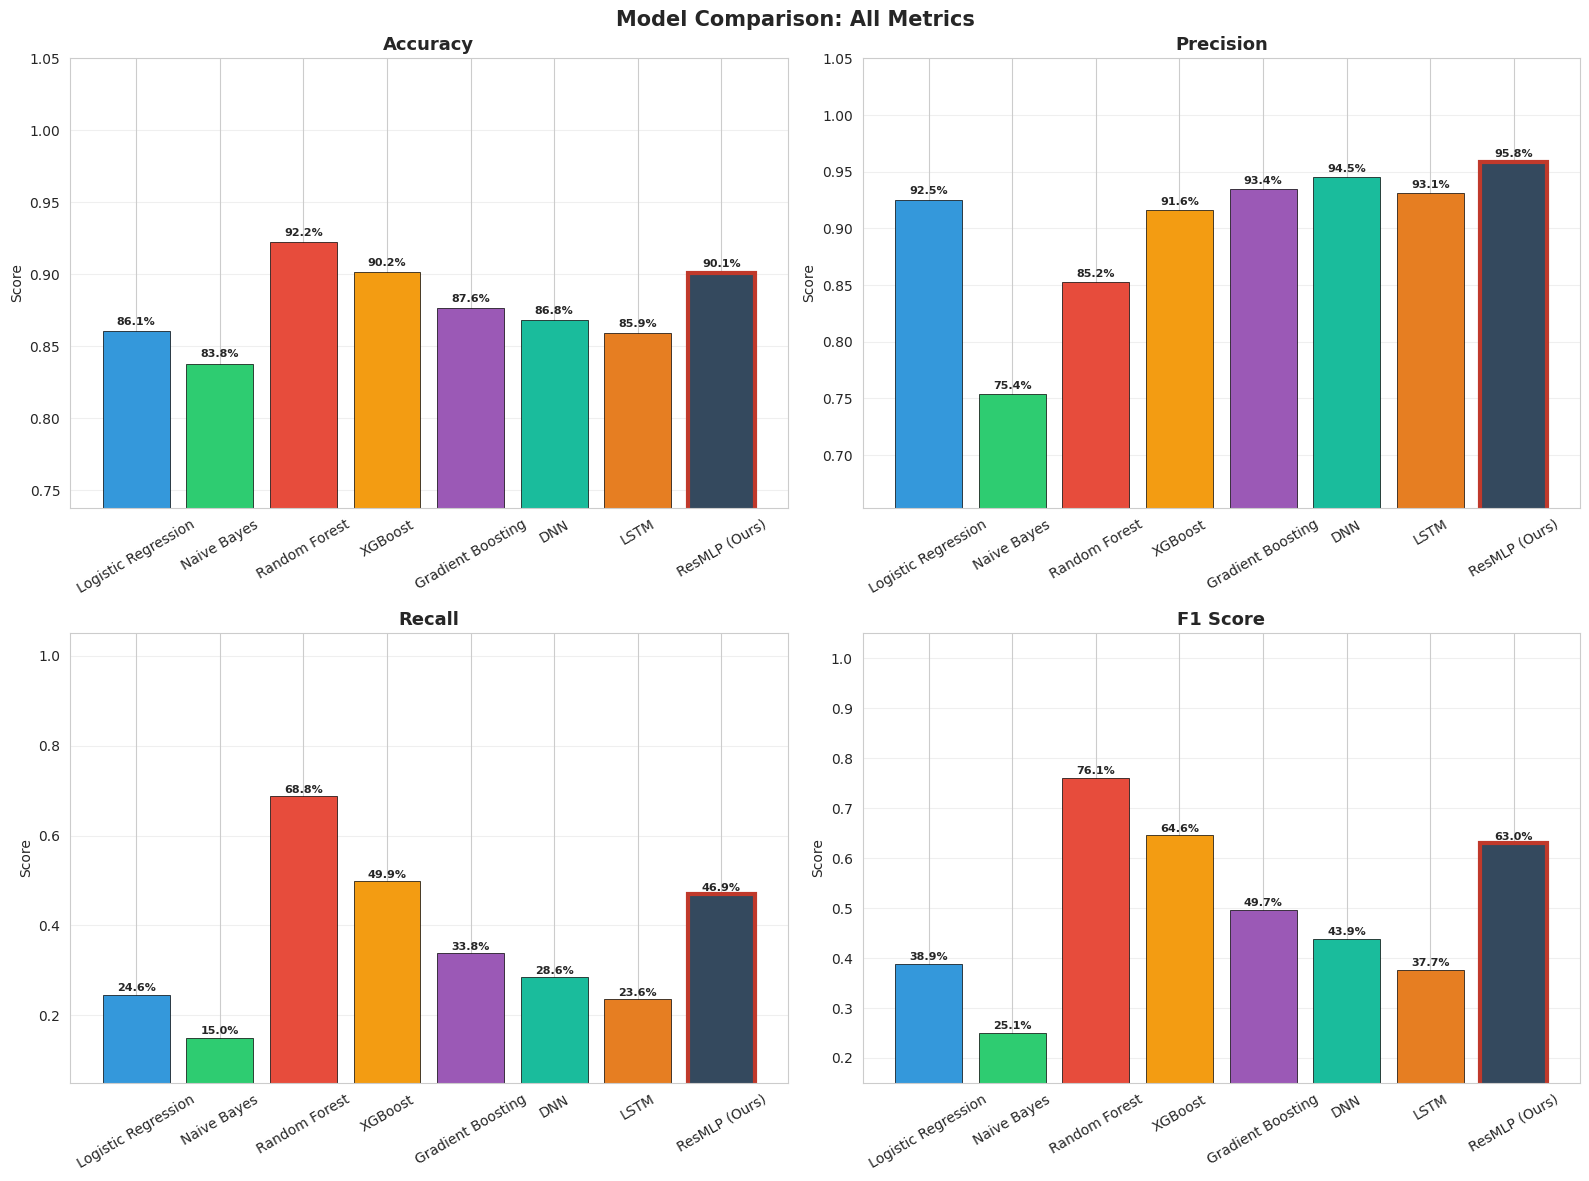

In [52]:
models = results_df.index.tolist()
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6', '#1abc9c', '#e67e22', '#34495e']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, metric in enumerate(metric_names):
    vals = results_df[metric].values.astype(float)
    bars = axes[i].bar(models, vals, color=colors[:len(models)], edgecolor='black', linewidth=0.5)
    axes[i].set_title(metric, fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Score')
    axes[i].set_ylim(max(0, min(vals) - 0.1), 1.05)
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].grid(True, alpha=0.3, axis='y')
    for bar, val in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.003,
                     f'{val*100:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
    # Highlight ResMLP bar
    for j, model in enumerate(models):
        if 'ResMLP' in model:
            bars[j].set_edgecolor('#c0392b')
            bars[j].set_linewidth(3)

plt.suptitle('Model Comparison: All Metrics', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/13_all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

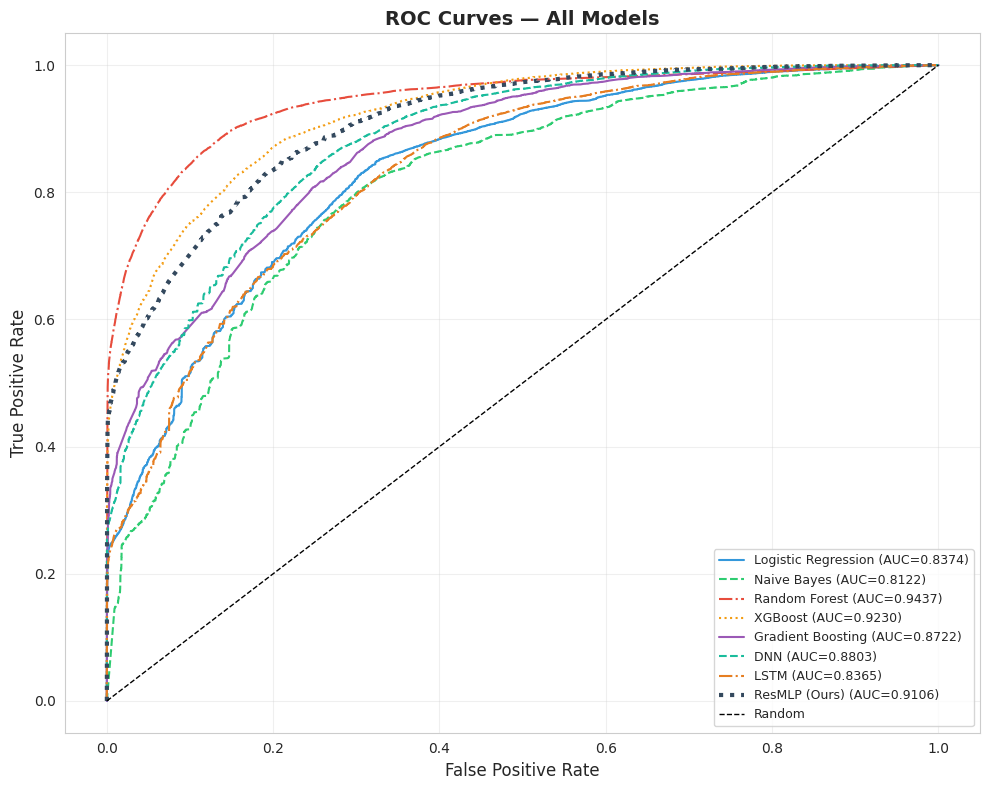

In [53]:
plt.figure(figsize=(10, 8))
line_styles = ['-', '--', '-.', ':', '-', '--', '-.', ':']

for i, (name, prob) in enumerate(all_probs.items()):
    if prob is not None:
        fpr, tpr, _ = roc_curve(y_test, prob)
        auc = roc_auc_score(y_test, prob)
        lw = 3 if 'ResMLP' in name else 1.5
        plt.plot(fpr, tpr, lw=lw, ls=line_styles[i % len(line_styles)],
                 color=colors[i % len(colors)],
                 label=f'{name} (AUC={auc:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/14_all_roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

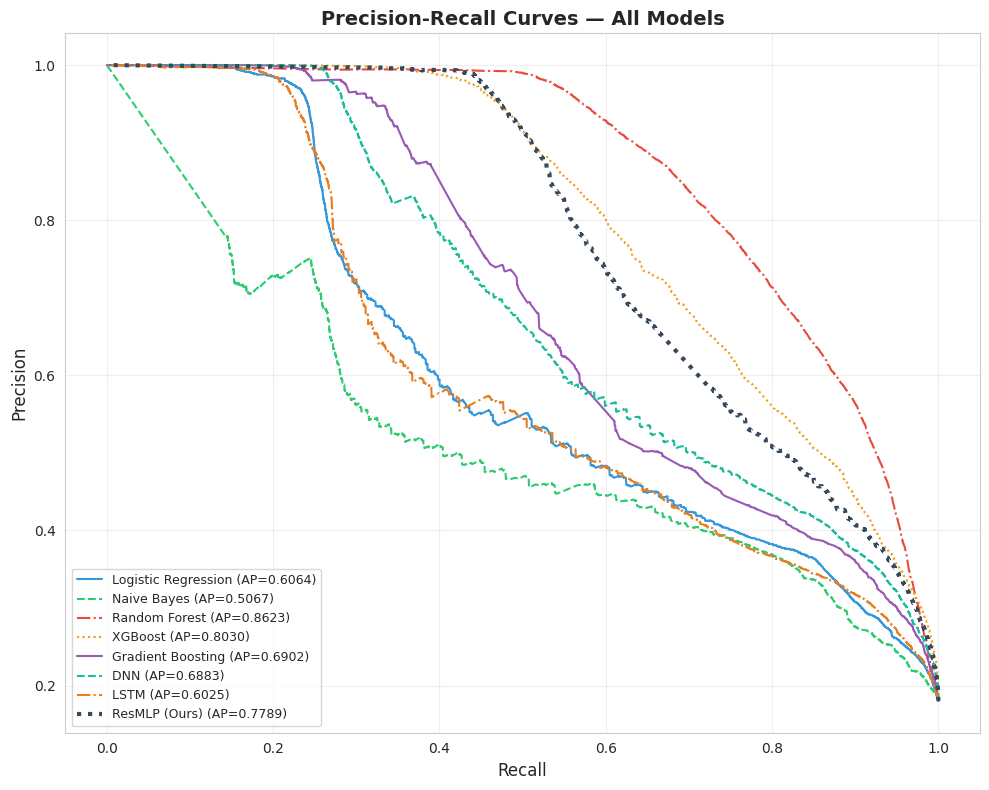

In [54]:
plt.figure(figsize=(10, 8))

for i, (name, prob) in enumerate(all_probs.items()):
    if prob is not None:
        prec_vals, rec_vals, _ = precision_recall_curve(y_test, prob)
        ap = average_precision_score(y_test, prob)
        lw = 3 if 'ResMLP' in name else 1.5
        plt.plot(rec_vals, prec_vals, lw=lw, ls=line_styles[i % len(line_styles)],
                 color=colors[i % len(colors)],
                 label=f'{name} (AP={ap:.4f})')

plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower left', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/15_all_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

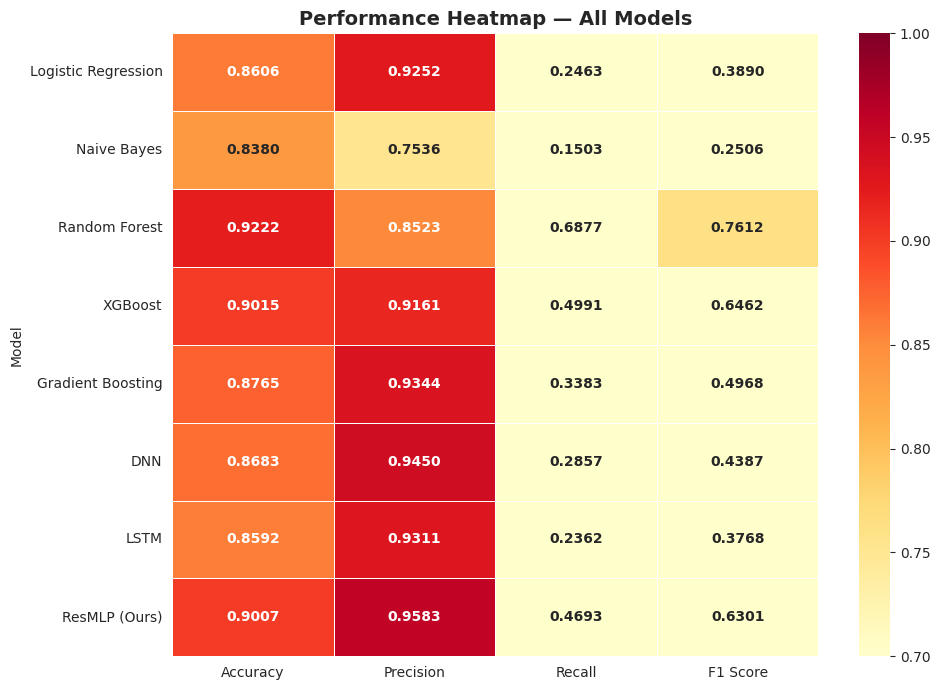

In [55]:
heat_data = results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].astype(float)

plt.figure(figsize=(10, 7))
sns.heatmap(heat_data, annot=True, fmt='.4f', cmap='YlOrRd',
            linewidths=0.5, vmin=0.7, vmax=1.0,
            annot_kws={'size': 10, 'weight': 'bold'})
plt.title('Performance Heatmap — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/16_performance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

In [56]:
# Paper's reported values (Table 5 from the paper)
paper_table5 = pd.DataFrame([
    {'Model': 'Random Forest (Paper)',       'Accuracy': 0.85, 'Precision': 0.78, 'Recall': 0.82, 'F1 Score': 0.80},
    {'Model': 'Rule-Based Heuristics (Paper)','Accuracy': 0.80, 'Precision': 0.72, 'Recall': 0.75, 'F1 Score': 0.73},
    {'Model': 'Deep Neural Network (Paper)', 'Accuracy': 0.88, 'Precision': 0.80, 'Recall': 0.85, 'F1 Score': 0.82},
    {'Model': 'Grad. Boosting (Paper)',      'Accuracy': 0.82, 'Precision': 0.75, 'Recall': 0.78, 'F1 Score': 0.76},
    {'Model': 'Domain Age Analysis (Paper)', 'Accuracy': 0.95, 'Precision': 0.88, 'Recall': 0.91, 'F1 Score': 0.89},
    {'Model': 'ResMLP (Paper)',              'Accuracy': 0.9829,'Precision': 0.93, 'Recall': 0.96, 'F1 Score': 0.94},
]).set_index('Model')

print('Paper Table 5 — Comparison of Phishing URL Detection Models:')
for col in paper_table5.columns:
    paper_table5[col+'_pct'] = paper_table5[col].apply(lambda x: f'{x*100:.1f}%')
print(paper_table5[['Accuracy_pct','Precision_pct','Recall_pct','F1 Score_pct']]
      .rename(columns=lambda c: c.replace('_pct',''))
      .to_string())

Paper Table 5 — Comparison of Phishing URL Detection Models:
                              Accuracy Precision Recall F1 Score
Model                                                           
Random Forest (Paper)            85.0%     78.0%  82.0%    80.0%
Rule-Based Heuristics (Paper)    80.0%     72.0%  75.0%    73.0%
Deep Neural Network (Paper)      88.0%     80.0%  85.0%    82.0%
Grad. Boosting (Paper)           82.0%     75.0%  78.0%    76.0%
Domain Age Analysis (Paper)      95.0%     88.0%  91.0%    89.0%
ResMLP (Paper)                   98.3%     93.0%  96.0%    94.0%


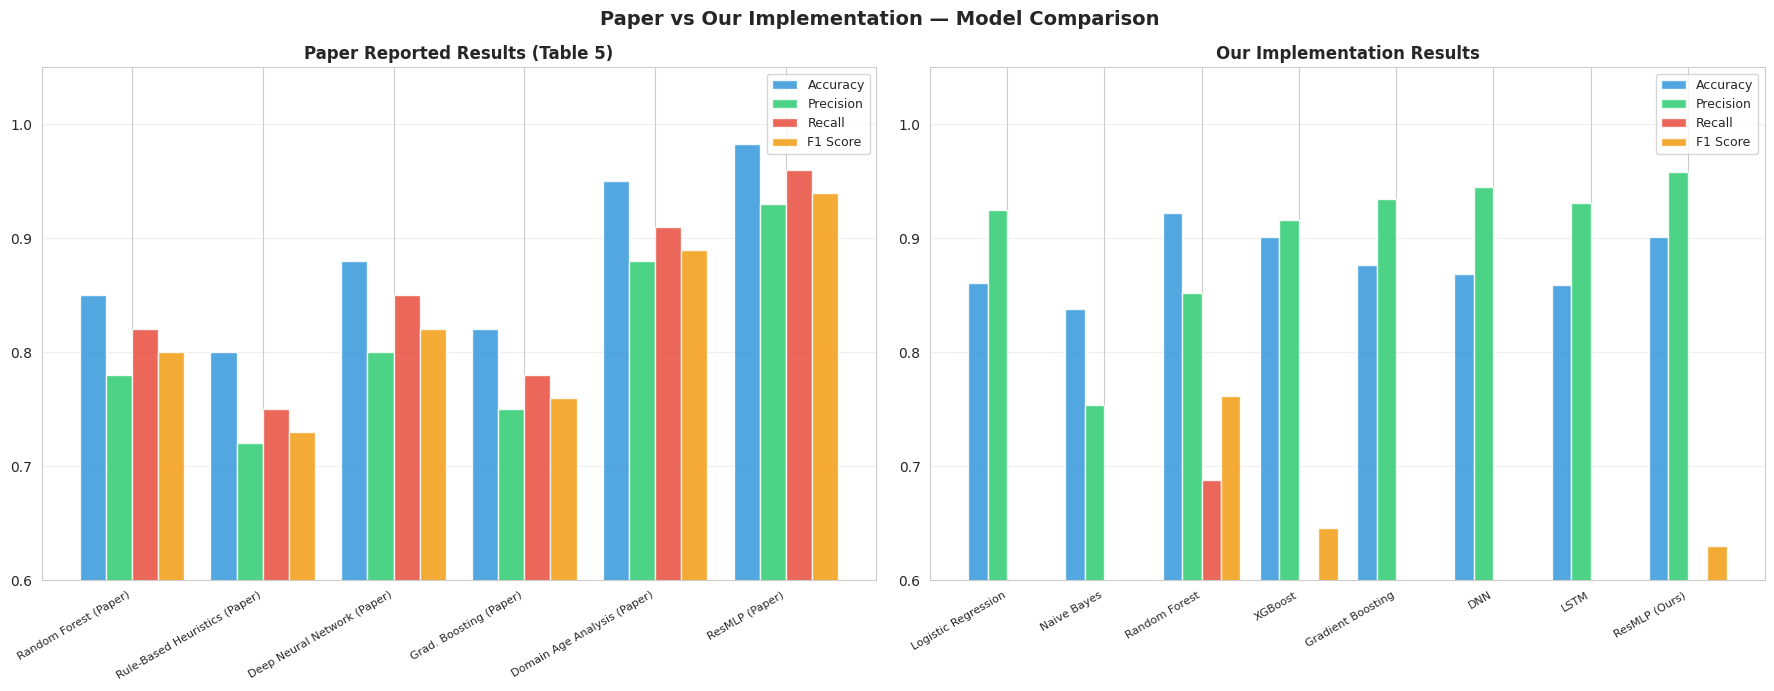

In [57]:
# Visual comparison: Paper reported vs Our results
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Paper results
paper_data = paper_table5[['Accuracy', 'Precision', 'Recall', 'F1 Score']]
x = np.arange(len(paper_data.index))
width = 0.2
metric_colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for j, (metric, color) in enumerate(zip(['Accuracy','Precision','Recall','F1 Score'], metric_colors)):
    axes[0].bar(x + j*width, paper_data[metric], width, label=metric, color=color, alpha=0.85)
axes[0].set_xticks(x + width*1.5)
axes[0].set_xticklabels(paper_data.index, rotation=30, ha='right', fontsize=8)
axes[0].set_ylim(0.6, 1.05)
axes[0].set_title('Paper Reported Results (Table 5)', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3, axis='y')

# Our results
our_data = results_df[['Accuracy', 'Precision', 'Recall', 'F1 Score']].astype(float)
x2 = np.arange(len(our_data.index))

for j, (metric, color) in enumerate(zip(['Accuracy','Precision','Recall','F1 Score'], metric_colors)):
    axes[1].bar(x2 + j*width, our_data[metric], width, label=metric, color=color, alpha=0.85)
axes[1].set_xticks(x2 + width*1.5)
axes[1].set_xticklabels(our_data.index, rotation=30, ha='right', fontsize=8)
axes[1].set_ylim(0.6, 1.05)
axes[1].set_title('Our Implementation Results', fontsize=12, fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3, axis='y')

plt.suptitle('Paper vs Our Implementation — Model Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/17_paper_vs_ours_full.png', dpi=150, bbox_inches='tight')
plt.show()

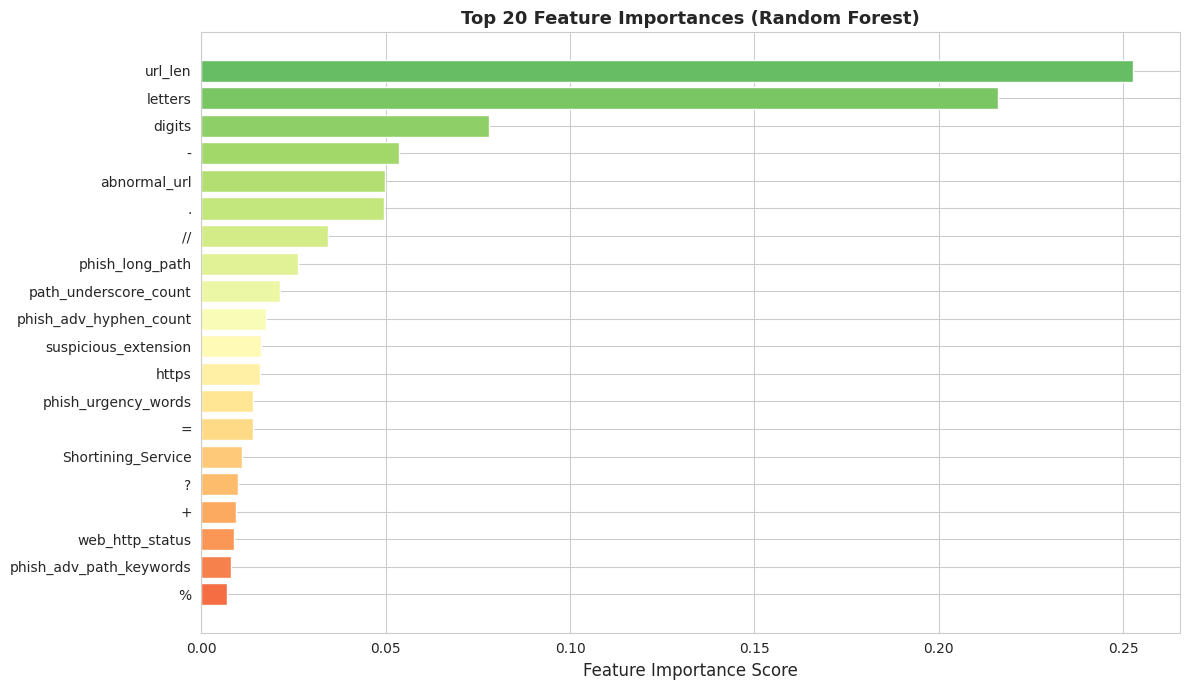

Top 10 most important features:
  url_len                                 : 0.2528
  letters                                 : 0.2159
  digits                                  : 0.0779
  -                                       : 0.0535
  abnormal_url                            : 0.0499
  .                                       : 0.0494
  //                                      : 0.0344
  phish_long_path                         : 0.0261
  path_underscore_count                   : 0.0214
  phish_adv_hyphen_count                  : 0.0174


In [58]:
with open('models/feature_cols.pkl', 'rb') as f:
    FEATURE_COLS = pickle.load(f)

feat_imp = pd.Series(rf.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False)

plt.figure(figsize=(12, 7))
top_n = 20
colors_imp = plt.cm.RdYlGn(np.linspace(0.8, 0.2, top_n))
plt.barh(range(top_n), feat_imp.values[:top_n], color=colors_imp)
plt.yticks(range(top_n), feat_imp.index[:top_n])
plt.gca().invert_yaxis()
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Top 20 Feature Importances (Random Forest)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/18_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 most important features:')
for feat, score in feat_imp.head(10).items():
    print(f'  {feat:40s}: {score:.4f}')

In [59]:
print('=' * 70)
print('         FINAL PROJECT RESULTS SUMMARY')
print('         CSCE 5215 — Machine Learning — Group 7')
print('=' * 70)
print(f'Paper: An Effective Detection Approach for Phishing URL Using ResMLP')
print(f'Dataset: {len(np.load("results/y_train.npy")) + len(np.load("results/y_test.npy")):,} URLs (phishing + benign)')
print()

# Rank models by F1 Score
ranked = results_df.copy()
ranked = ranked.sort_values('F1 Score', ascending=False)

print(f'{"Rank":<5} {"Model":<30} {"Accuracy":>10} {"Precision":>10} {"Recall":>10} {"F1 Score":>10}')
print('-' * 75)
for rank, (model, row) in enumerate(ranked.iterrows(), 1):
    marker = ' <-- BEST' if rank == 1 else ''
    print(f'{rank:<5} {model:<30} {row["Accuracy"]*100:>9.2f}% {row["Precision"]*100:>9.2f}% {row["Recall"]*100:>9.2f}% {row["F1 Score"]*100:>9.2f}%{marker}')

print()
print(f'Paper reported ResMLP accuracy: 98.29%')
print('=' * 70)

# Save final summary
ranked.to_csv('results/final_ranked_results.csv')
print('\nAll results saved to results/ folder.')
print('All plots saved to plots/ folder.')

         FINAL PROJECT RESULTS SUMMARY
         CSCE 5215 — Machine Learning — Group 7
Paper: An Effective Detection Approach for Phishing URL Using ResMLP
Dataset: 522,214 URLs (phishing + benign)

Rank  Model                            Accuracy  Precision     Recall   F1 Score
---------------------------------------------------------------------------
1     Random Forest                      92.22%     85.23%     68.77%     76.12% <-- BEST
2     XGBoost                            90.15%     91.61%     49.91%     64.62%
3     ResMLP (Ours)                      90.07%     95.83%     46.93%     63.01%
4     Gradient Boosting                  87.65%     93.44%     33.83%     49.68%
5     DNN                                86.83%     94.50%     28.57%     43.87%
6     Logistic Regression                86.06%     92.52%     24.63%     38.90%
7     LSTM                               85.92%     93.11%     23.62%     37.68%
8     Naive Bayes                        83.80%     75.36%     15.03